In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

In [2]:
df = pd.read_csv('../data/josaa_data.csv')

In [3]:
print(df.head())
print(df.columns.tolist())
print(df.shape)

                                    Institute  \
0  Indian Institute of Technology Bhubaneswar   
1  Indian Institute of Technology Bhubaneswar   
2  Indian Institute of Technology Bhubaneswar   
3  Indian Institute of Technology Bhubaneswar   
4  Indian Institute of Technology Bhubaneswar   

                               Academic Program Name Quota Seat Type  \
0  Civil Engineering (4 Years, Bachelor of Techno...    AI      OPEN   
1  Civil Engineering (4 Years, Bachelor of Techno...    AI      OPEN   
2  Civil Engineering (4 Years, Bachelor of Techno...    AI   OBC-NCL   
3  Civil Engineering (4 Years, Bachelor of Techno...    AI   OBC-NCL   
4  Civil Engineering (4 Years, Bachelor of Techno...    AI        SC   

                                  Gender  Opening Rank  Closing Rank  Round  \
0                         Gender-Neutral        5057.0        6780.0      1   
1  Female-only (including Supernumerary)       10078.0       10789.0      1   
2                         Gender-Ne

In [4]:
# What years are available?
print("Years:", sorted(df['Year'].unique()))

# What rounds are available?
print("Rounds:", sorted(df['Round'].unique()))

# How many unique institutes?
print("Institutes:", df['Institute'].nunique())

# Check missing values
print("\nMissing values:")
print(df.isnull().sum())

Years: [np.int64(2018), np.int64(2019), np.int64(2020), np.int64(2021), np.int64(2022), np.int64(2023), np.int64(2024), np.int64(2025)]
Rounds: [np.int64(1), np.int64(2), np.int64(3), np.int64(4), np.int64(5), np.int64(6), np.int64(7)]
Institutes: 160

Missing values:
Institute                   0
Academic Program Name       1
Quota                       1
Seat Type                   2
Gender                      3
Opening Rank             1468
Closing Rank             1469
Round                       0
Year                        0
dtype: int64


In [5]:
# Keep only the last round for each year
final_round = df.groupby('Year')['Round'].max().reset_index()
print("Last round per year:")
print(final_round)

Last round per year:
   Year  Round
0  2018      7
1  2019      7
2  2020      6
3  2021      6
4  2022      6
5  2023      6
6  2024      5
7  2025      6


In [6]:
# Keep only final round rows
df_final = df[df['Round'] == df.groupby('Year')['Round'].transform('max')]

print("Shape after keeping final round:", df_final.shape)
print(df_final.head())

Shape after keeping final round: (75418, 9)
                                        Institute  \
41151  Indian Institute of Technology Bhubaneswar   
41152  Indian Institute of Technology Bhubaneswar   
41153  Indian Institute of Technology Bhubaneswar   
41154  Indian Institute of Technology Bhubaneswar   
41155  Indian Institute of Technology Bhubaneswar   

                                   Academic Program Name Quota Seat Type  \
41151  Civil Engineering (4 Years, Bachelor of Techno...    AI      OPEN   
41152  Civil Engineering (4 Years, Bachelor of Techno...    AI      OPEN   
41153  Civil Engineering (4 Years, Bachelor of Techno...    AI   OBC-NCL   
41154  Civil Engineering (4 Years, Bachelor of Techno...    AI   OBC-NCL   
41155  Civil Engineering (4 Years, Bachelor of Techno...    AI        SC   

                                      Gender  Opening Rank  Closing Rank  \
41151                         Gender-Neutral        5663.0        8116.0   
41152  Female-only (includin

In [7]:
# Drop rows where Closing Rank is missing — we can't use those
df_clean = df_final.dropna(subset=['Closing Rank', 'Opening Rank', 'Gender', 'Seat Type', 'Quota'])

print("Shape after dropping missing:", df_clean.shape)

Shape after dropping missing: (75008, 9)


In [8]:
df_clean = df_clean.copy()

df_clean['Seat_Key'] = (
    df_clean['Institute'] + ' | ' +
    df_clean['Academic Program Name'] + ' | ' +
    df_clean['Quota'] + ' | ' +
    df_clean['Seat Type'] + ' | ' +
    df_clean['Gender']
)

print("Total unique seats:", df_clean['Seat_Key'].nunique())
print("\nExample seat key:")
print(df_clean['Seat_Key'].iloc[0])

Total unique seats: 21390

Example seat key:
Indian Institute of Technology Bhubaneswar | Civil Engineering (4 Years, Bachelor of Technology) | AI | OPEN | Gender-Neutral


In [9]:
df_clean = df_clean.copy()

df_clean['Seat_Key'] = (
    df_clean['Institute'] + ' | ' +
    df_clean['Academic Program Name'] + ' | ' +
    df_clean['Quota'] + ' | ' +
    df_clean['Seat Type'] + ' | ' +
    df_clean['Gender']
)

print("Total unique seats:", df_clean['Seat_Key'].nunique())
print("\nExample seat key:")
print(df_clean['Seat_Key'].iloc[0])

Total unique seats: 21390

Example seat key:
Indian Institute of Technology Bhubaneswar | Civil Engineering (4 Years, Bachelor of Technology) | AI | OPEN | Gender-Neutral


In [10]:
years_per_seat = df_clean.groupby('Seat_Key')['Year'].count()

print("Distribution of years per seat:")
print(years_per_seat.value_counts().sort_index())

# Keep only seats that appear in at least 3 years
valid_seats = years_per_seat[years_per_seat >= 3].index
df_model = df_clean[df_clean['Seat_Key'].isin(valid_seats)]

print("\nShape after keeping seats with 3+ years:", df_model.shape)
print("Unique seats remaining:", df_model['Seat_Key'].nunique())

Distribution of years per seat:
Year
1    9084
2    1910
3    1348
4    1166
5    1062
6    1464
7    3554
8    1794
9       8
Name: count, dtype: int64

Shape after keeping seats with 3+ years: (62104, 10)
Unique seats remaining: 10396


Matching keys: ['Indian Institute of Technology Bombay | Computer Science and Engineering (4 Years, Bachelor of Technology) | AI | OPEN | Gender-Neutral', 'Indian Institute of Technology Bombay | Computer Science and Engineering (4 Years, Bachelor of Technology) | AI | OPEN (PwD) | Gender-Neutral', 'Indian Institute of Technology Bombay | Mechanical Engineering and M.Tech. in Computer Integrated Manufacturing (5 Years, Bachelor and Master of Technology (Dual Degree)) | AI | OPEN | Gender-Neutral']


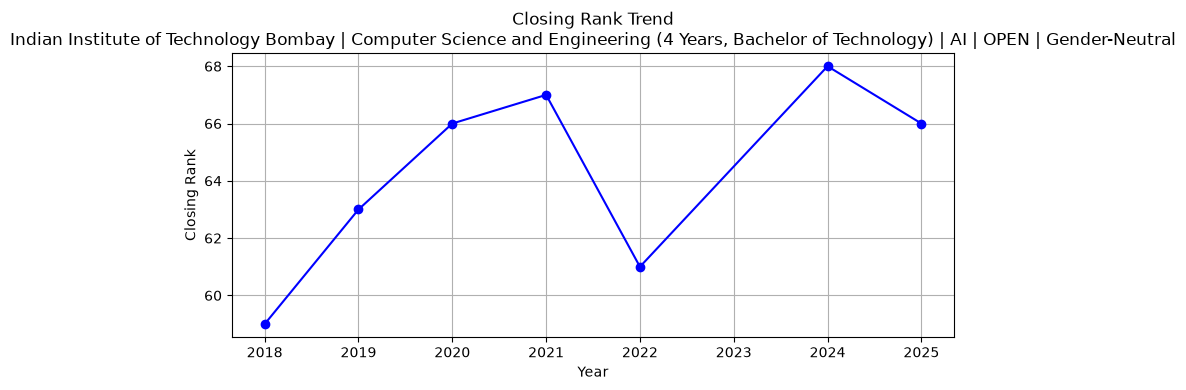

In [11]:
# Pick IIT Bombay CSE as a test
test_key = [k for k in df_model['Seat_Key'].unique() if 'Bombay' in k and 'Computer' in k and 'OPEN' in k and 'Gender-Neutral' in k]

print("Matching keys:", test_key)

if test_key:
    seat_data = df_model[df_model['Seat_Key'] == test_key[0]].sort_values('Year')
    
    plt.figure(figsize=(8, 4))
    plt.plot(seat_data['Year'], seat_data['Closing Rank'], marker='o', color='blue')
    plt.title(f"Closing Rank Trend\n{test_key[0]}")
    plt.xlabel("Year")
    plt.ylabel("Closing Rank")
    plt.grid(True)
    plt.tight_layout()
    plt.show()